# UAS Kecerdasan Buatan

# Prediksi Nilai Akademik Mahasiswa Menggunakan Algoritma Decision Tree dan Random Forest

**Disusun Oleh**

- Nama : Assyifa
- NIM : (Isi NIM)
- Program Studi : Teknik Informatika
- Fakultas : Fakultas Teknologi Industri
- Universitas : Institut Teknologi Garut

---

## Metode

Penelitian ini menggunakan metodologi **CRISP-DM (Cross Industry Standard Process for Data Mining)** yang terdiri dari enam tahapan:

1. Business Understanding
2. Data Understanding
3. Exploratory Data Analysis (EDA)
4. Data Preparation
5. Modeling
6. Evaluation

# Daftar Isi

1. Business Understanding
2. Data Understanding
3. Exploratory Data Analysis
4. Data Preparation
5. Modeling
6. Evaluation
7. Conclusion

# UAS Kecerdasan Buatan

# Prediksi Nilai Akademik Mahasiswa Menggunakan Algoritma Decision Tree dan Random Forest

---

## Business Understanding

### Latar Belakang

Prestasi akademik merupakan salah satu indikator keberhasilan mahasiswa dalam proses pembelajaran di perguruan tinggi. Berbagai faktor, seperti kebiasaan belajar, kehadiran di kelas, aktivitas membaca, kemampuan mencatat materi, serta keterlibatan dalam proyek pembelajaran dapat memengaruhi hasil akademik mahasiswa.

Dengan memanfaatkan teknik Machine Learning, institusi pendidikan dapat membangun model prediksi yang mampu memperkirakan nilai akademik mahasiswa berdasarkan karakteristik dan aktivitas belajar. Hasil prediksi ini diharapkan dapat membantu dosen maupun program studi dalam mengidentifikasi mahasiswa yang memerlukan pendampingan akademik lebih awal sehingga proses pembelajaran menjadi lebih efektif.

### Permasalahan

Program studi umumnya baru mengetahui mahasiswa yang mengalami penurunan prestasi setelah nilai akhir diumumkan. Hal tersebut menyebabkan proses pendampingan akademik sering terlambat dilakukan.

### Tujuan

- Membangun model prediksi nilai akademik mahasiswa menggunakan algoritma Decision Tree dan Random Forest.
- Membandingkan performa kedua algoritma berdasarkan metrik evaluasi.
- Menentukan algoritma terbaik dalam memprediksi nilai akademik mahasiswa.

### Pengguna Sistem

- Dosen
- Program Studi
- Mahasiswa

### Manfaat

- Membantu dosen mengidentifikasi mahasiswa yang berpotensi mengalami penurunan prestasi.
- Mendukung pengambilan keputusan berbasis data.
- Memberikan gambaran mengenai faktor-faktor yang memengaruhi nilai akademik mahasiswa.

In [140]:
# =====================================================
# Import Library
# =====================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import is_string_dtype
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Semua library berhasil diimpor.")

Semua library berhasil diimpor.


## Dataset

Dataset yang digunakan merupakan dataset **Student Performance** yang berisi karakteristik mahasiswa, aktivitas belajar, serta nilai akademik yang diperoleh mahasiswa.

Dataset terdiri atas **145 data** dengan **16 atribut**, di mana variabel **Grade** digunakan sebagai target klasifikasi.

In [141]:
from pandas.api.types import is_string_dtype

for col in eda_df.columns:
    if is_string_dtype(eda_df[col]):
        eda_df[col] = le.fit_transform(eda_df[col])

In [142]:
df = pd.read_csv("data/dataset/student.csv")



# Data Understanding

## Sumber Dataset

Dataset yang digunakan adalah **Student Performance Dataset** yang diperoleh dari Kaggle. Dataset ini berisi informasi mengenai karakteristik mahasiswa, kebiasaan belajar, aktivitas akademik, serta nilai akademik (Grade).

Dataset digunakan untuk membangun model klasifikasi yang mampu memprediksi nilai akademik mahasiswa berdasarkan berbagai faktor yang memengaruhi proses belajar.

## Tujuan Data Understanding

Tahap ini bertujuan untuk memahami struktur dataset sebelum dilakukan proses analisis dan pemodelan. Beberapa aspek yang dianalisis meliputi:

- Jumlah data dan atribut
- Struktur dataset
- Tipe data
- Statistik deskriptif
- Missing value
- Duplikasi data
- Distribusi variabel target

In [143]:
# Menampilkan 5 data pertama
df.head()

,Unnamed: 0,Id,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,0,5001,21,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,1,5002,20,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,2,5003,21,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,3,5004,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,4,5005,22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


### Preview Dataset

Lima data pertama digunakan untuk memperoleh gambaran awal mengenai isi dataset, nama atribut, serta jenis informasi yang tersedia sebelum dilakukan analisis lebih lanjut.

In [144]:
print("Jumlah Baris dan Kolom :", df.shape)

print("\nInformasi Dataset\n")
df.info()

Jumlah Baris dan Kolom : (145, 16)

Informasi Dataset

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          145 non-null    int64
 1   Id                  145 non-null    int64
 2   Student_Age         145 non-null    int64
 3   Sex                 145 non-null    str  
 4   High_School_Type    145 non-null    str  
 5   Scholarship         144 non-null    str  
 6   Additional_Work     145 non-null    str  
 7   Sports_activity     145 non-null    str  
 8   Transportation      145 non-null    str  
 9   Weekly_Study_Hours  145 non-null    int64
 10  Attendance          145 non-null    str  
 11  Reading             145 non-null    str  
 12  Notes               145 non-null    str  
 13  Listening_in_Class  145 non-null    str  
 14  Project_work        145 non-null    str  
 15  Grade               145 non-null    str  
dtype

### Informasi Dataset

Tahapan ini digunakan untuk mengetahui:

- Jumlah baris dan kolom
- Nama atribut
- Tipe data setiap atribut
- Banyaknya data yang tidak kosong (non-null)

Informasi tersebut akan menjadi dasar dalam menentukan teknik preprocessing yang akan digunakan.

In [145]:
df.describe(include="all")

,Unnamed: 0,Id,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
count,145.000000,145.000000,145.000000,145,145,144,145,145,145,145.000000,145,145,145,145,145,145
unique,NaN,NaN,NaN,2,3,4,2,2,2,NaN,4,2,3,3,2,8
top,NaN,NaN,NaN,Male,State,50%,No,No,Private,NaN,Always,No,Yes,Yes,No,AA
freq,NaN,NaN,NaN,87,103,76,96,87,84,NaN,98,76,77,75,73,35
mean,72.000000,5073.000000,19.682759,NaN,NaN,NaN,NaN,NaN,NaN,2.331034,NaN,NaN,NaN,NaN,NaN,NaN
std,42.001984,42.001984,1.992010,NaN,NaN,NaN,NaN,NaN,NaN,4.249273,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,5001.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,36.000000,5037.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,72.000000,5073.000000,19.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,108.000000,5109.000000,21.000000,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN


### Statistik Deskriptif

Statistik deskriptif memberikan gambaran umum mengenai distribusi data.

Untuk atribut numerik akan ditampilkan informasi seperti:

- Mean
- Standar deviasi
- Nilai minimum
- Nilai maksimum

Sedangkan atribut kategorikal akan menampilkan jumlah kategori, nilai yang paling sering muncul (top), dan frekuensinya.

In [146]:
missing = df.isnull().sum()

missing

Unnamed: 0            0
Id                    0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64

In [147]:
missing_df = pd.DataFrame({
    "Kolom": df.columns,
    "Missing Value": df.isnull().sum(),
    "Persentase (%)": round(df.isnull().mean()*100,2)
})

missing_df

,Kolom,Missing Value,Persentase (%)
Unnamed: 0,Unnamed: 0,0,0.00
Id,Id,0,0.00
Student_Age,Student_Age,0,0.00
Sex,Sex,0,0.00
High_School_Type,High_School_Type,0,0.00
Scholarship,Scholarship,1,0.69
Additional_Work,Additional_Work,0,0.00
Sports_activity,Sports_activity,0,0.00
Transportation,Transportation,0,0.00
Weekly_Study_Hours,Weekly_Study_Hours,0,0.00


### Analisis Missing Value

Tahap ini dilakukan untuk mengetahui apakah terdapat data yang kosong pada setiap atribut.

Apabila ditemukan missing value, maka akan dilakukan penanganan pada tahap Data Preparation.

Sebaliknya, apabila tidak terdapat missing value, maka dataset dapat langsung digunakan pada proses selanjutnya.

In [148]:
duplicate = df.duplicated().sum()

print("Jumlah data duplikat :", duplicate)

Jumlah data duplikat : 0


### Analisis Data Duplikat

Data duplikat dapat menyebabkan bias pada proses pelatihan model Machine Learning.

Oleh karena itu dilakukan pemeriksaan untuk memastikan bahwa setiap data merupakan observasi yang unik.

In [149]:
df.columns

Index(['Unnamed: 0', 'Id', 'Student_Age', 'Sex', 'High_School_Type',
       'Scholarship', 'Additional_Work', 'Sports_activity', 'Transportation',
       'Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes',
       'Listening_in_Class', 'Project_work', 'Grade'],
      dtype='str')

## Deskripsi Atribut Dataset

Berikut adalah penjelasan singkat setiap atribut yang digunakan dalam penelitian.

| No | Nama Atribut | Deskripsi |
|----|--------------|-----------|
| 1 | Student_Age | Usia mahasiswa |
| 2 | Sex | Jenis kelamin mahasiswa |
| 3 | High_School_Type | Jenis sekolah asal |
| 4 | Scholarship | Status penerimaan beasiswa |
| 5 | Additional_Work | Memiliki pekerjaan sampingan |
| 6 | Sports_activity | Aktivitas olahraga |
| 7 | Transportation | Transportasi menuju kampus |
| 8 | Weekly_Study_Hours | Jam belajar per minggu |
| 9 | Attendance | Tingkat kehadiran |
|10 | Reading | Kebiasaan membaca |
|11 | Notes | Kebiasaan mencatat materi |
|12 | Listening_in_Class | Tingkat perhatian saat perkuliahan |
|13 | Project_work | Partisipasi dalam pengerjaan proyek |
|14 | Grade | Nilai akademik mahasiswa (Target) |

In [150]:
df["Grade"].value_counts().sort_index()

Grade
AA      35
BA      24
BB      21
CB      10
CC      17
DC      13
DD      17
Fail     8
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

## Tujuan

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik data melalui visualisasi dan analisis statistik. Tahap ini bertujuan untuk mengidentifikasi pola, hubungan antar variabel, distribusi data, serta potensi permasalahan yang dapat memengaruhi proses pemodelan Machine Learning.

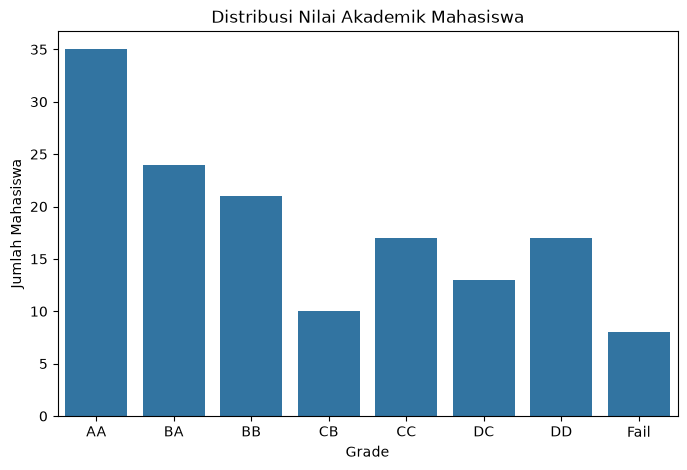

In [151]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Grade",
    order=sorted(df["Grade"].unique())
)

plt.title("Distribusi Nilai Akademik Mahasiswa")
plt.xlabel("Grade")
plt.ylabel("Jumlah Mahasiswa")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "distribusi_nilai_akademik_mahasiswa.png"), bbox_inches="tight")

plt.show()

### Insight

Visualisasi di atas menunjukkan distribusi jumlah mahasiswa pada setiap kategori nilai (Grade). Apabila terdapat perbedaan jumlah yang cukup besar antar kategori, maka dataset dapat dikatakan mengalami ketidakseimbangan kelas (class imbalance) yang perlu diperhatikan pada tahap pemodelan.

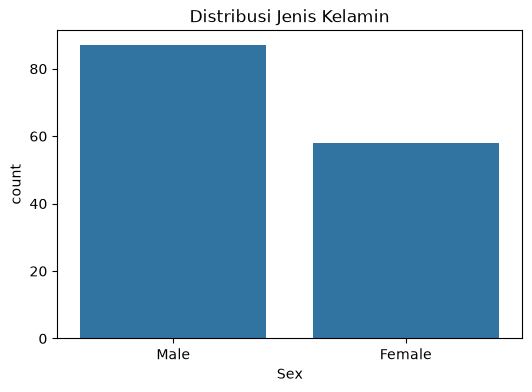

In [152]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Sex"
)

plt.title("Distribusi Jenis Kelamin")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "distribusi_jenis_kelamin.png"), bbox_inches="tight")

plt.show()

### Insight

Grafik ini menunjukkan proporsi mahasiswa berdasarkan jenis kelamin pada dataset.

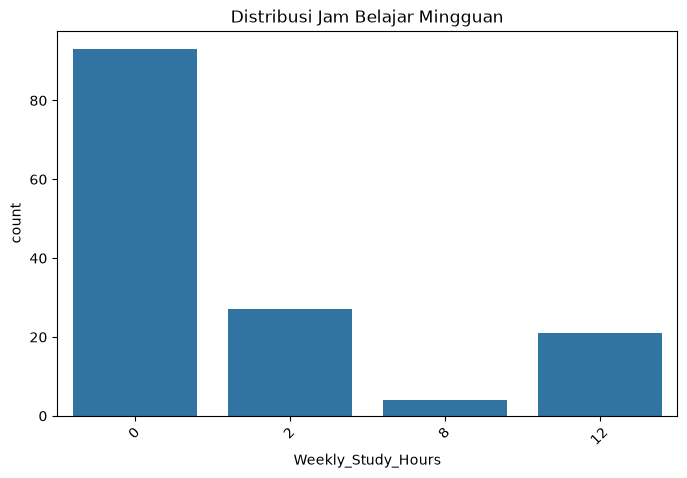

In [153]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Weekly_Study_Hours"
)

plt.title("Distribusi Jam Belajar Mingguan")

plt.xticks(rotation=45)

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "distribusi_jam_belajar_mingguan.png"), bbox_inches="tight")

plt.show()

### Insight

Visualisasi ini menunjukkan distribusi kebiasaan belajar mahasiswa berdasarkan jumlah jam belajar setiap minggu.

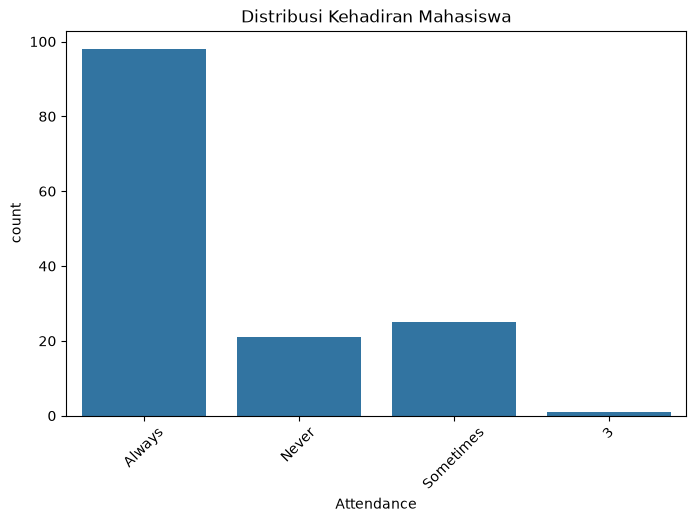

In [154]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Attendance"
)

plt.title("Distribusi Kehadiran Mahasiswa")

plt.xticks(rotation=45)

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "distribusi_kehadiran_mahasiswa.png"), bbox_inches="tight")

plt.show()

### Insight

Kehadiran merupakan salah satu faktor yang diduga memiliki pengaruh terhadap nilai akademik mahasiswa.

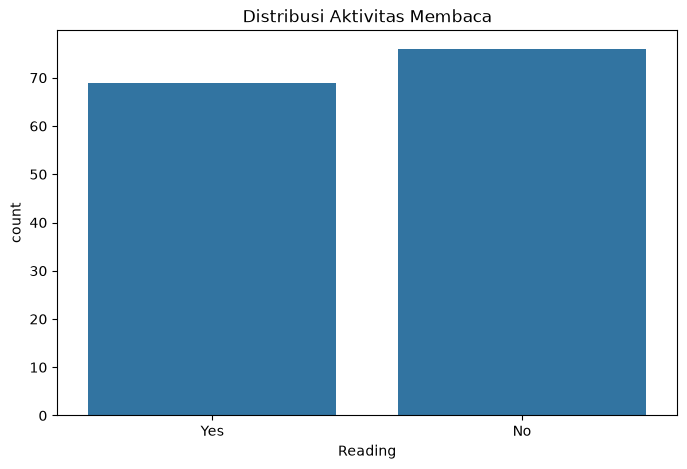

In [155]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Reading"
)

plt.title("Distribusi Aktivitas Membaca")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "distribusi_aktivitas_membaca.png"), bbox_inches="tight")

plt.show()

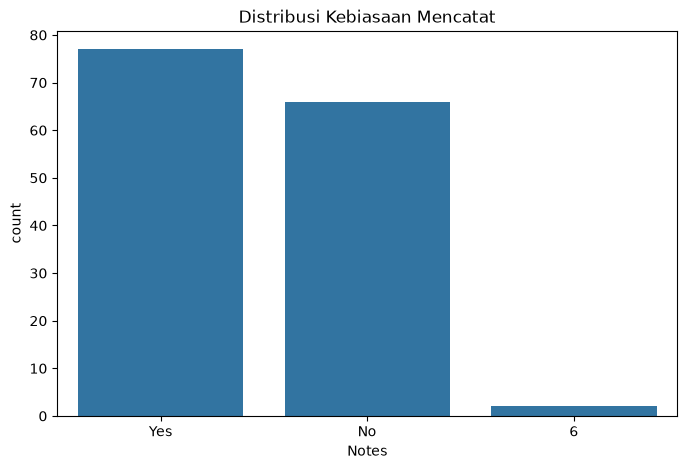

In [156]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Notes"
)

plt.title("Distribusi Kebiasaan Mencatat")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "distribusi_kebiasaan_mencatat.png"), bbox_inches="tight")

plt.show()

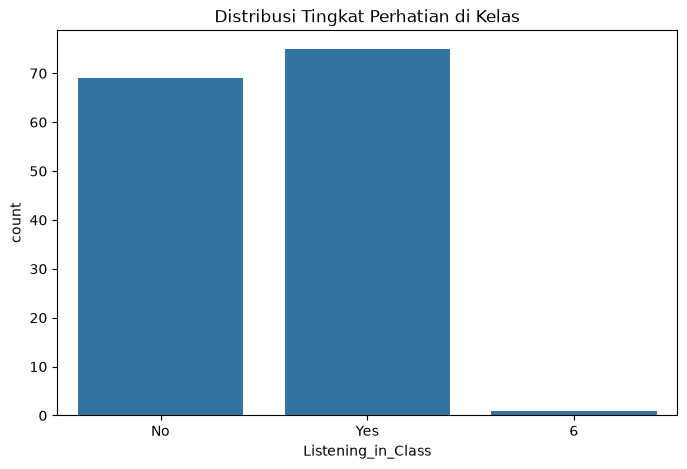

In [157]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Listening_in_Class"
)

plt.title("Distribusi Tingkat Perhatian di Kelas")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "distribusi_tingkat_perhatian_di_kelas.png"), bbox_inches="tight")

plt.show()

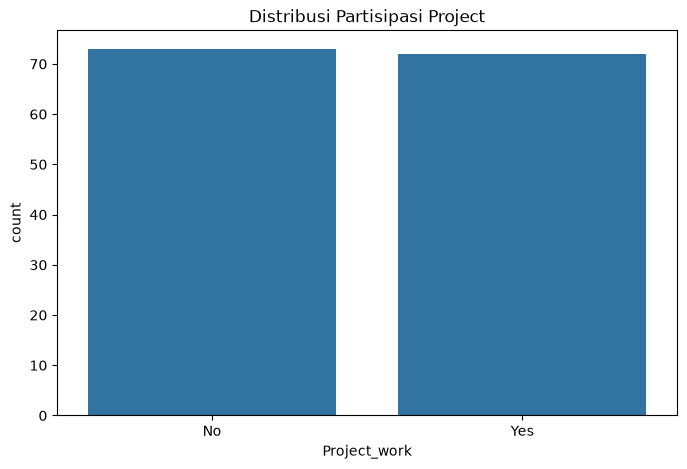

In [158]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Project_work"
)

plt.title("Distribusi Partisipasi Project")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "distribusi_partisipasi_project.png"), bbox_inches="tight")

plt.show()

## Analisis Hubungan Antar Variabel

Sebelum membuat model Machine Learning, perlu dilakukan analisis hubungan antar variabel. Karena sebagian besar atribut masih berupa data kategorikal, maka seluruh atribut akan diubah sementara menjadi numerik menggunakan Label Encoding agar dapat dihitung korelasinya.

In [159]:
eda_df = df.copy()

le = LabelEncoder()

for col in eda_df.columns:
    if is_string_dtype(eda_df[col]):
        eda_df[col] = le.fit_transform(eda_df[col])

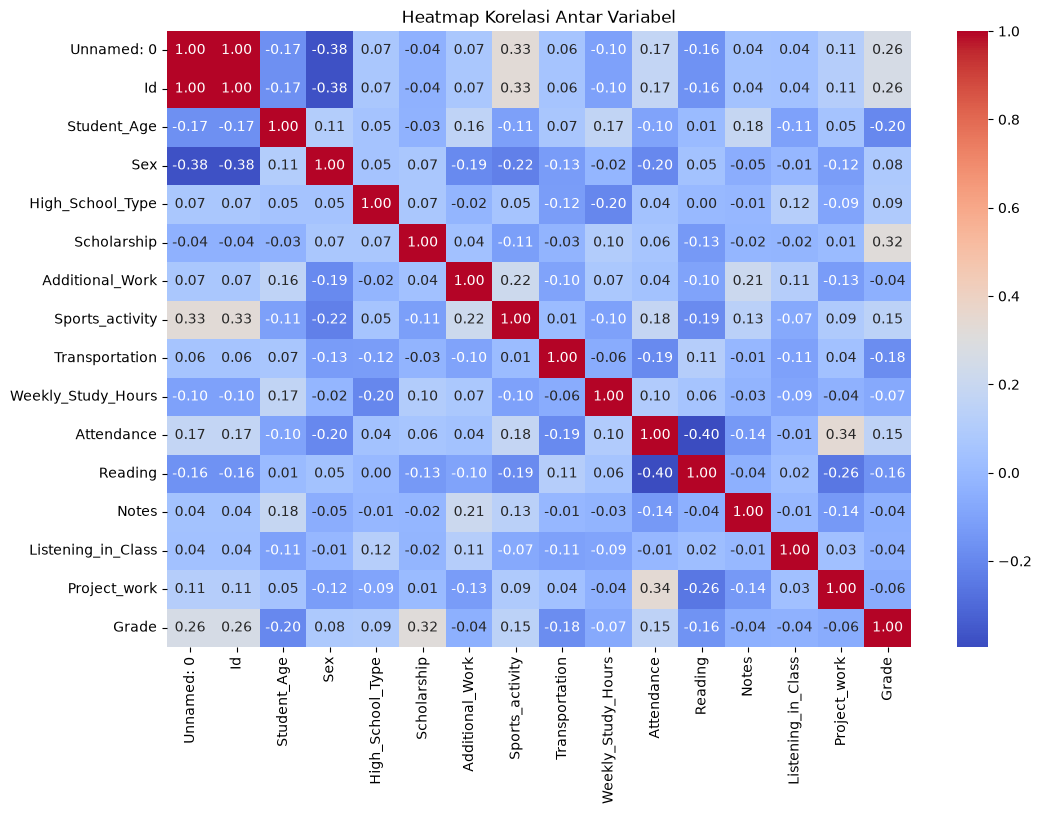

In [160]:
plt.figure(figsize=(12,8))

sns.heatmap(
    eda_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heatmap Korelasi Antar Variabel")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "heatmap_korelasi_antar_variabel.png"), bbox_inches="tight")

plt.show()

### Insight

Heatmap menunjukkan tingkat hubungan antar atribut dalam dataset. Nilai korelasi yang mendekati 1 menunjukkan hubungan positif yang kuat, sedangkan nilai mendekati -1 menunjukkan hubungan negatif yang kuat. Korelasi yang rendah menunjukkan hubungan yang lemah antar variabel.

In [161]:
corr_grade = eda_df.corr()["Grade"].sort_values(ascending=False)

corr_grade

Grade                 1.000000
Scholarship           0.317674
Id                    0.259055
Unnamed: 0            0.259055
Attendance            0.154536
Sports_activity       0.148211
High_School_Type      0.093382
Sex                   0.084517
Listening_in_Class   -0.037999
Notes                -0.040867
Additional_Work      -0.043002
Project_work         -0.061001
Weekly_Study_Hours   -0.068097
Reading              -0.157153
Transportation       -0.177425
Student_Age          -0.196827
Name: Grade, dtype: float64

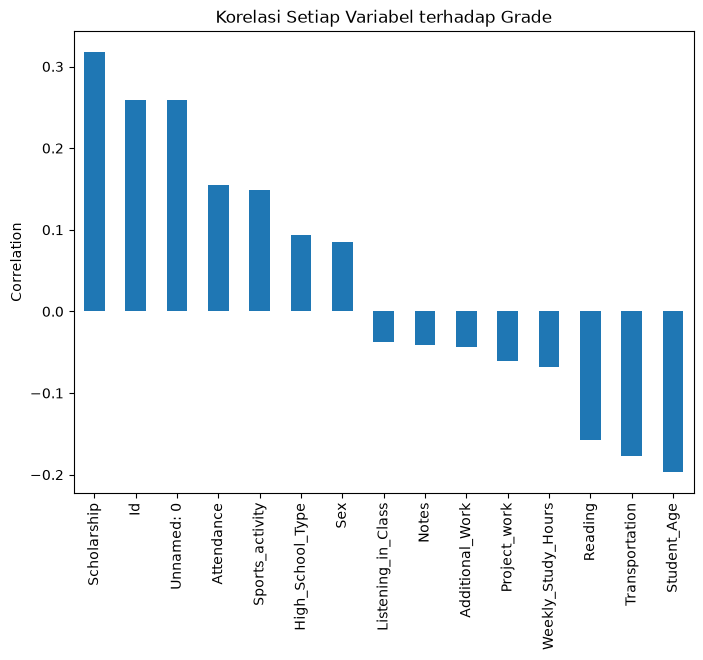

In [162]:
plt.figure(figsize=(8,6))

corr_grade.drop("Grade").plot(kind="bar")

plt.title("Korelasi Setiap Variabel terhadap Grade")

plt.ylabel("Correlation")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "korelasi_setiap_variabel_terhadap_grade.png"), bbox_inches="tight")

plt.show()

### Insight

Grafik di atas menunjukkan atribut yang memiliki hubungan paling kuat terhadap nilai akademik mahasiswa. Informasi ini dapat menjadi dasar dalam memahami faktor-faktor yang berpotensi memengaruhi hasil belajar mahasiswa.

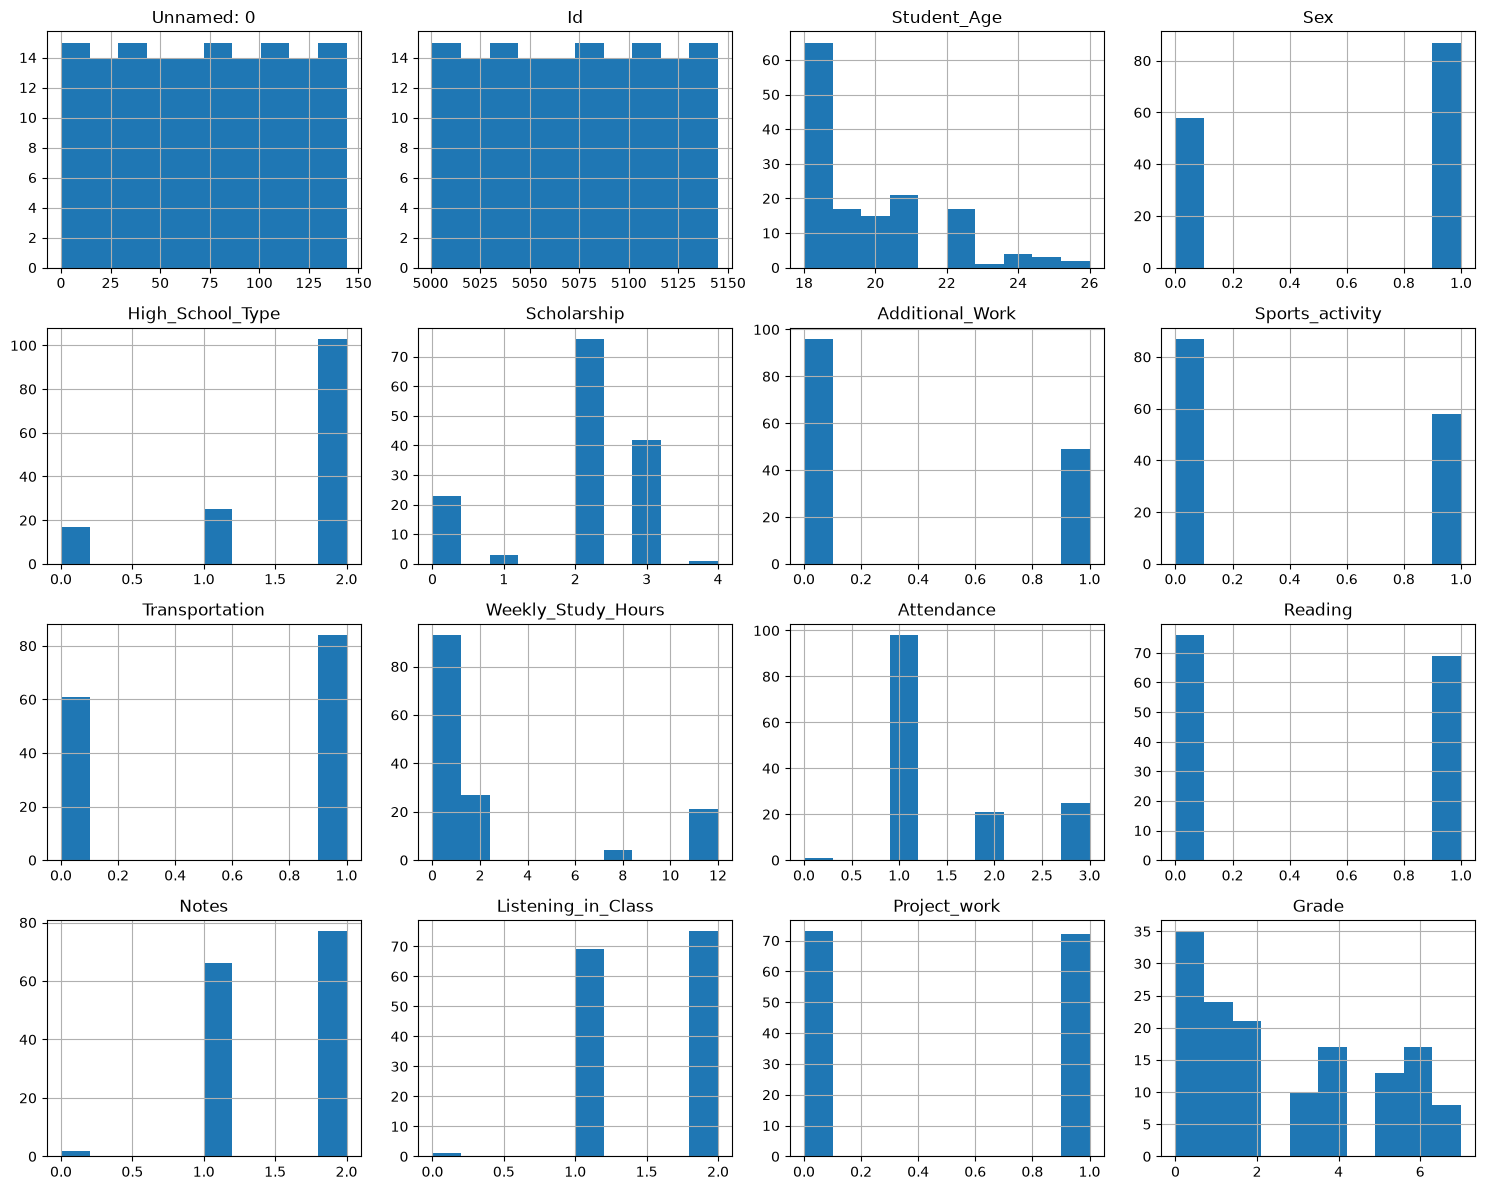

In [163]:
eda_df.hist(figsize=(15,12))

plt.tight_layout()

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "eda_hist.png"), bbox_inches="tight")

plt.show()

## Kesimpulan EDA

Berdasarkan hasil Exploratory Data Analysis, diperoleh beberapa temuan awal sebagai berikut:

- Distribusi nilai akademik menunjukkan penyebaran data pada beberapa kategori Grade.
- Sebagian besar atribut tidak memiliki nilai kosong sehingga dataset siap untuk tahap preprocessing.
- Heatmap memberikan gambaran hubungan antar variabel, meskipun interpretasi tetap perlu mempertimbangkan bahwa sebagian data kategorikal telah diubah menjadi numerik untuk keperluan visualisasi.
- Beberapa atribut menunjukkan hubungan yang lebih kuat dengan variabel target dibandingkan atribut lainnya.
- Hasil EDA menjadi dasar dalam proses Data Preparation dan pemilihan model Machine Learning pada tahap berikutnya.

# Data Preparation

## Tujuan

Data Preparation merupakan tahapan untuk menyiapkan dataset sebelum proses pemodelan Machine Learning. Pada tahap ini dilakukan pembersihan data, pemilihan atribut, transformasi data kategorikal menjadi numerik, serta pembagian data menjadi data latih dan data uji.

In [164]:
# Membuat salinan dataset
data = df.copy()

# Menampilkan ukuran dataset
print("Ukuran dataset :", data.shape)

Ukuran dataset : (145, 16)


In [165]:
# Menghapus kolom yang tidak digunakan

drop_columns = ["Unnamed: 0", "Id"]

data.drop(columns=drop_columns, inplace=True)

data.head()

,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,21,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,20,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,21,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


### Pemilihan Atribut

Kolom **Unnamed: 0** dan **Id** dihapus karena hanya berfungsi sebagai identitas data dan tidak memiliki kontribusi dalam proses prediksi nilai akademik mahasiswa.

In [166]:
print(data.isnull().sum())

Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Weekly_Study_Hours    0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
dtype: int64


### Missing Value

Hasil pemeriksaan menunjukkan apakah masih terdapat nilai kosong setelah proses pembersihan data. Jika tidak ditemukan missing value, maka dataset dapat langsung diproses pada tahap berikutnya.

In [167]:
# Label Encoding

label_encoder = LabelEncoder()

for column in data.columns:
    if is_string_dtype(data[column]):
        data[column] = label_encoder.fit_transform(data[column])

data.head()

,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,21,1,0,2,1,0,1,0,1,1,2,1,0,0
1,20,1,0,2,1,0,1,0,1,1,1,2,1,0
2,21,1,2,2,0,0,1,2,2,0,1,1,1,0
3,18,0,1,2,1,0,0,2,1,0,2,1,0,0
4,22,1,1,2,0,0,0,12,1,1,1,2,1,0


### Label Encoding

Label Encoding digunakan untuk mengubah data kategorikal menjadi bentuk numerik sehingga dapat diproses oleh algoritma Machine Learning.

In [168]:
X = data.drop("Grade", axis=1)

y = data["Grade"]

print("Jumlah Feature :", X.shape[1])
print("Jumlah Data :", X.shape[0])

Jumlah Feature : 13
Jumlah Data : 145


### Feature dan Target

Variabel independen (X) terdiri dari seluruh atribut selain **Grade**, sedangkan variabel dependen (y) adalah **Grade** yang akan diprediksi oleh model.

In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Latih :", X_train.shape)
print("Data Uji :", X_test.shape)

Data Latih : (116, 13)
Data Uji : (29, 13)


### Pembagian Dataset

Dataset dibagi menjadi:

- **80%** data latih (training)
- **20%** data uji (testing)

Pembagian ini bertujuan agar model dapat dilatih menggunakan data latih dan dievaluasi menggunakan data uji yang belum pernah dilihat sebelumnya.

In [170]:
print("Distribusi Grade pada Data Latih")
print(y_train.value_counts())

print("\nDistribusi Grade pada Data Uji")
print(y_test.value_counts())

Distribusi Grade pada Data Latih
Grade
0    28
1    19
2    17
6    14
4    14
5    10
3     8
7     6
Name: count, dtype: int64

Distribusi Grade pada Data Uji
Grade
0    7
1    5
2    4
5    3
4    3
6    3
3    2
7    2
Name: count, dtype: int64


In [171]:
print("="*50)
print("Dataset Siap Digunakan")
print("="*50)

print(f"Jumlah Data          : {len(data)}")
print(f"Jumlah Feature       : {X.shape[1]}")
print(f"Jumlah Target        : {y.nunique()}")
print(f"Data Training        : {len(X_train)}")
print(f"Data Testing         : {len(X_test)}")

Dataset Siap Digunakan
Jumlah Data          : 145
Jumlah Feature       : 13
Jumlah Target        : 8
Data Training        : 116
Data Testing         : 29


## Kesimpulan Data Preparation

Tahap Data Preparation telah berhasil dilakukan dengan beberapa proses sebagai berikut:

- Menghapus atribut yang tidak memiliki pengaruh terhadap proses prediksi.
- Memastikan dataset tidak memiliki missing value.
- Mengubah seluruh atribut kategorikal menjadi numerik menggunakan Label Encoding.
- Menentukan variabel feature dan target.
- Membagi dataset menjadi data latih dan data uji dengan rasio 80:20.

Dataset telah siap digunakan pada tahap pemodelan Machine Learning.

## Kesimpulan Data Preparation

Tahap Data Preparation telah berhasil dilakukan dengan beberapa proses sebagai berikut:

- Menghapus atribut yang tidak memiliki pengaruh terhadap proses prediksi.
- Memastikan dataset tidak memiliki missing value.
- Mengubah seluruh atribut kategorikal menjadi numerik menggunakan Label Encoding.
- Menentukan variabel feature dan target.
- Membagi dataset menjadi data latih dan data uji dengan rasio 80:20.

Dataset telah siap digunakan pada tahap pemodelan Machine Learning.

# Modeling

## Tujuan

Tahap Modeling bertujuan untuk membangun model Machine Learning yang mampu memprediksi nilai akademik mahasiswa berdasarkan data yang telah dipersiapkan.

Pada penelitian ini digunakan dua algoritma klasifikasi, yaitu:

1. Decision Tree
2. Random Forest

Kedua algoritma dipilih karena mampu menangani data kategorikal yang telah dikonversi menjadi numerik serta mudah diinterpretasikan.

## Model 1 - Decision Tree

Decision Tree merupakan algoritma klasifikasi berbasis struktur pohon yang membagi data berdasarkan atribut tertentu hingga diperoleh keputusan klasifikasi.

In [172]:
# =====================================================
# Decision Tree
# =====================================================

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Model Decision Tree berhasil dilatih.")

Model Decision Tree berhasil dilatih.


In [173]:
# Prediksi Decision Tree

y_pred_dt = dt_model.predict(X_test)

print("Prediksi berhasil dilakukan.")

Prediksi berhasil dilakukan.


In [174]:
# Contoh hasil prediksi

prediction_dt = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred_dt
})

prediction_dt.head(10)

,Actual,Prediction
73,5,2
91,5,4
54,2,6
140,4,0
37,0,0
76,3,0
8,4,0
64,2,1
20,0,0
104,2,2


## Model 2 - Random Forest

Random Forest merupakan pengembangan dari Decision Tree yang membangun banyak pohon keputusan (ensemble) untuk meningkatkan akurasi dan mengurangi risiko overfitting.

In [175]:
# =====================================================
# Random Forest
# =====================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


In [176]:
# Prediksi Random Forest

y_pred_rf = rf_model.predict(X_test)

print("Prediksi berhasil dilakukan.")

Prediksi berhasil dilakukan.


In [177]:
prediction_rf = pd.DataFrame({
    "Actual": y_test,
    "Prediction": y_pred_rf
})

prediction_rf.head(10)

,Actual,Prediction
73,5,4
91,5,4
54,2,0
140,4,1
37,0,0
76,3,0
8,4,0
64,2,0
20,0,0
104,2,0


## Feature Importance

Feature Importance digunakan untuk mengetahui atribut mana yang paling berpengaruh terhadap hasil prediksi pada algoritma Random Forest.

In [178]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Student_Age,0.152403
3,Scholarship,0.101589
7,Weekly_Study_Hours,0.087756
8,Attendance,0.077304
11,Listening_in_Class,0.076289
2,High_School_Type,0.074947
10,Notes,0.066943
5,Sports_activity,0.064579
1,Sex,0.064468
12,Project_work,0.063351


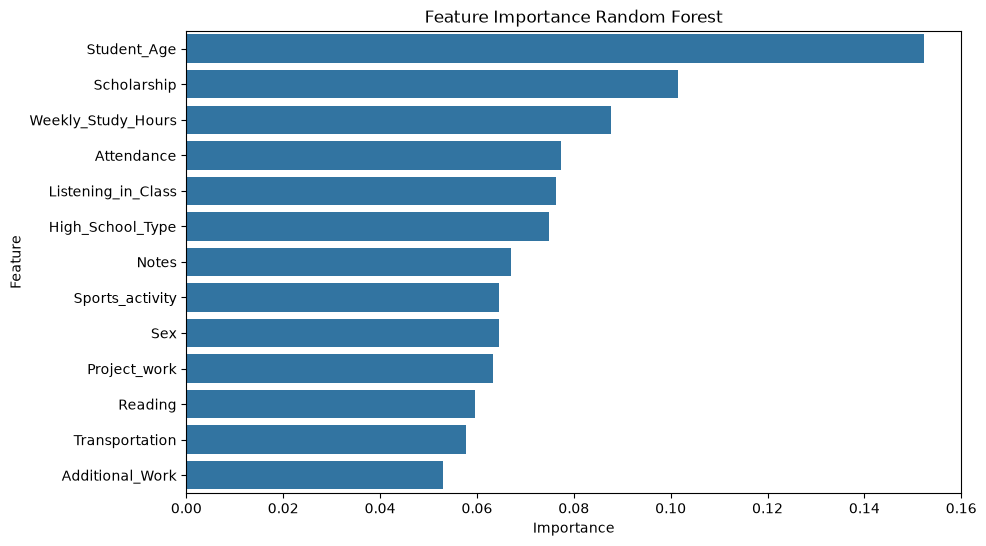

In [179]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance Random Forest")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "feature_importance_random_forest.png"), bbox_inches="tight")

plt.show()

## Visualisasi Decision Tree

Visualisasi pohon keputusan membantu memahami bagaimana model melakukan proses klasifikasi berdasarkan atribut-atribut yang tersedia.

In [180]:
from sklearn.tree import plot_tree

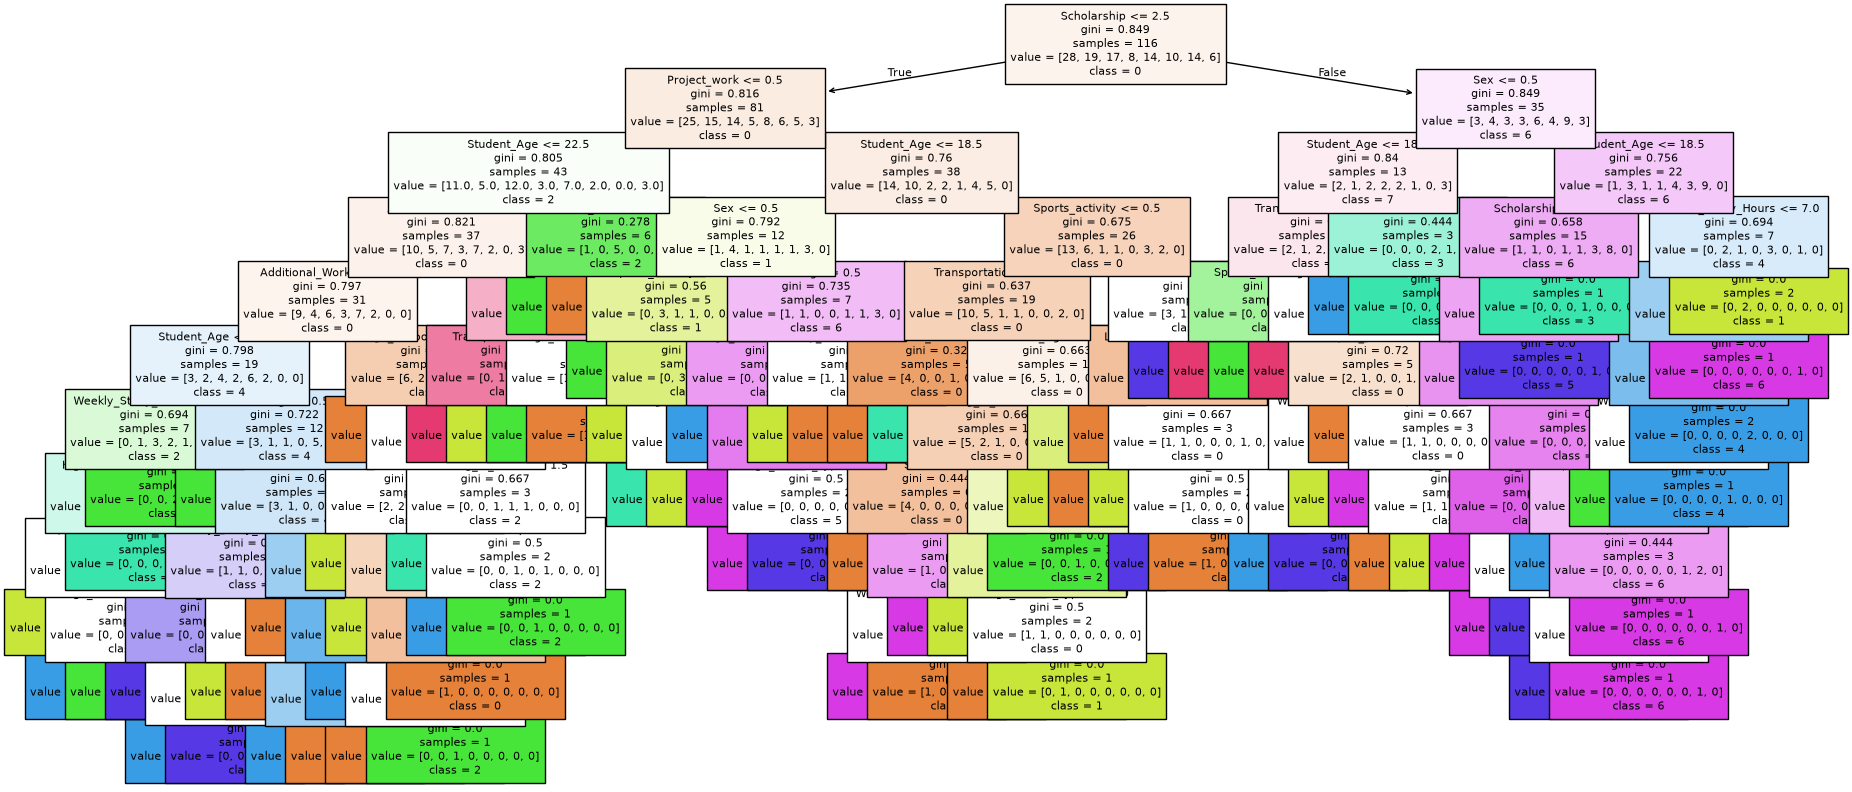

In [181]:
plt.figure(figsize=(22,10))

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=[str(i) for i in sorted(y.unique())],
    fontsize=8
)

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "decision_tree_plot.png"), bbox_inches="tight")

plt.show()

## Hasil Pemodelan

Kedua model telah berhasil dibangun menggunakan data latih.

Selanjutnya akan dilakukan evaluasi performa model menggunakan beberapa metrik, yaitu:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

Evaluasi dilakukan terhadap data uji untuk mengetahui kemampuan model dalam melakukan prediksi terhadap data yang belum pernah digunakan pada proses pelatihan.

## Hasil Pemodelan

Kedua model telah berhasil dibangun menggunakan data latih.

Selanjutnya akan dilakukan evaluasi performa model menggunakan beberapa metrik, yaitu:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

Evaluasi dilakukan terhadap data uji untuk mengetahui kemampuan model dalam melakukan prediksi terhadap data yang belum pernah digunakan pada proses pelatihan.

In [182]:
# =====================================================
# Evaluasi Decision Tree
# =====================================================

accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    average='weighted'
)

print("Decision Tree")

print("-"*40)

print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1 Score  : {f1_dt:.4f}")

Decision Tree
----------------------------------------
Accuracy  : 0.1724
Precision : 0.1422
Recall    : 0.1724
F1 Score  : 0.1540


In [183]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.38      0.43      0.40         7
           1       0.00      0.00      0.00         5
           2       0.12      0.25      0.17         4
           3       0.00      0.00      0.00         2
           4       0.33      0.33      0.33         3
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         2

    accuracy                           0.17        29
   macro avg       0.10      0.13      0.11        29
weighted avg       0.14      0.17      0.15        29



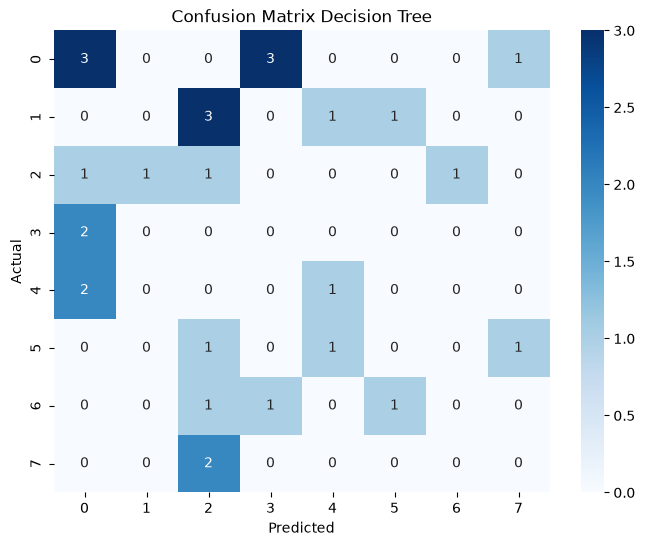

In [184]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_dt,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Confusion Matrix Decision Tree")

plt.xlabel("Predicted")

plt.ylabel("Actual")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "confusion_matrix_decision_tree.png"), bbox_inches="tight")

plt.show()

### Analisis Decision Tree

Confusion Matrix menunjukkan jumlah prediksi yang benar maupun salah pada setiap kelas.

Semakin banyak nilai pada diagonal utama, semakin baik kemampuan model dalam melakukan klasifikasi.

In [185]:
# =====================================================
# Evaluasi Random Forest
# =====================================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='weighted'
)

print("Random Forest")

print("-"*40)

print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")

Random Forest
----------------------------------------
Accuracy  : 0.2069
Precision : 0.1954
Recall    : 0.2069
F1 Score  : 0.1879


In [186]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.21      0.43      0.29         7
           1       0.33      0.20      0.25         5
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.50      0.33      0.40         3
           7       0.50      0.50      0.50         2

    accuracy                           0.21        29
   macro avg       0.19      0.18      0.18        29
weighted avg       0.20      0.21      0.19        29



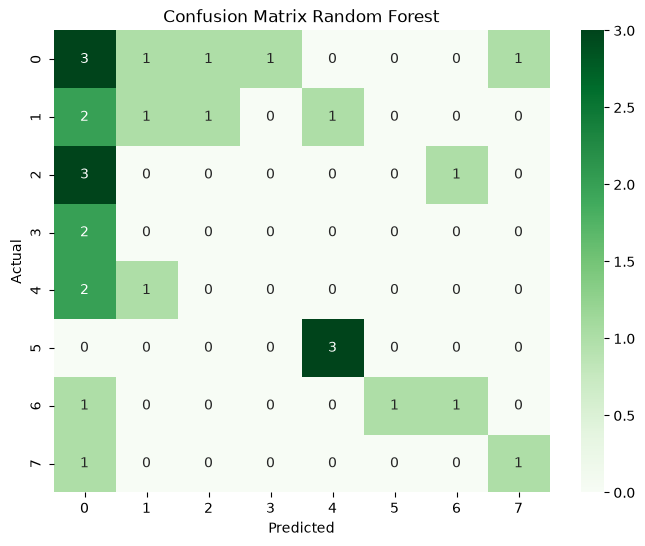

In [187]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    cmap="Greens",
    fmt="d"
)

plt.title("Confusion Matrix Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "confusion_matrix_random_forest.png"), bbox_inches="tight")

plt.show()

### Analisis Random Forest

Confusion Matrix digunakan untuk melihat kemampuan model dalam mengklasifikasikan setiap kategori nilai akademik mahasiswa.

Semakin tinggi jumlah prediksi benar pada diagonal utama, semakin baik performa model.

In [188]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_dt,
        accuracy_rf
    ],

    "Precision":[
        precision_dt,
        precision_rf
    ],

    "Recall":[
        recall_dt,
        recall_rf
    ],

    "F1 Score":[
        f1_dt,
        f1_rf
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.172414,0.142241,0.172414,0.154023
1,Random Forest,0.206897,0.195402,0.206897,0.187931


In [189]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_dt,
        accuracy_rf
    ],

    "Precision":[
        precision_dt,
        precision_rf
    ],

    "Recall":[
        recall_dt,
        recall_rf
    ],

    "F1 Score":[
        f1_dt,
        f1_rf
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.172414,0.142241,0.172414,0.154023
1,Random Forest,0.206897,0.195402,0.206897,0.187931


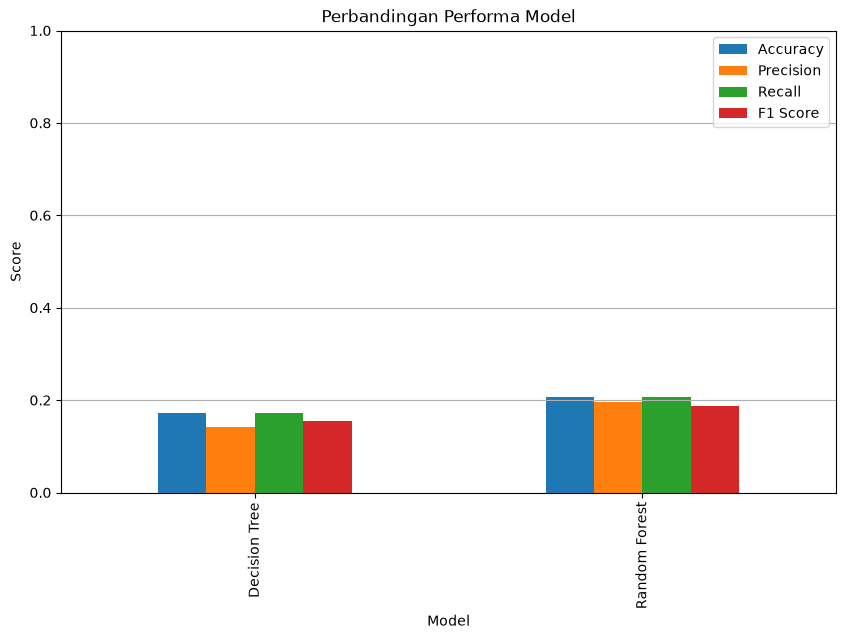

In [190]:
comparison_plot = comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Perbandingan Performa Model")

plt.ylabel("Score")

plt.ylim(0,1)

plt.grid(axis="y")

os.makedirs("data", exist_ok=True)
plt.savefig(os.path.join("data", "perbandingan_performa_model.png"), bbox_inches="tight")

plt.show()

## Hasil Perbandingan Model

Berdasarkan hasil evaluasi, kedua algoritma menunjukkan performa yang berbeda pada proses klasifikasi nilai akademik mahasiswa.

Model dengan nilai Accuracy, Precision, Recall, dan F1-Score yang lebih tinggi dapat dipilih sebagai model terbaik untuk kasus prediksi nilai akademik mahasiswa.

In [191]:
if accuracy_rf > accuracy_dt:
    print("Model Terbaik : Random Forest")
else:
    print("Model Terbaik : Decision Tree")

Model Terbaik : Random Forest


# Kesimpulan

Penelitian ini berhasil membangun model Machine Learning untuk memprediksi nilai akademik mahasiswa menggunakan algoritma Decision Tree dan Random Forest.

Tahapan penelitian meliputi:

- Business Understanding
- Data Understanding
- Exploratory Data Analysis
- Data Preparation
- Modeling
- Evaluation

Berdasarkan hasil evaluasi, model dengan performa terbaik dipilih berdasarkan nilai Accuracy, Precision, Recall, dan F1-Score.

Model terbaik diharapkan dapat membantu dosen maupun program studi dalam melakukan identifikasi dini terhadap mahasiswa yang berpotensi mengalami penurunan prestasi akademik sehingga tindakan pendampingan dapat dilakukan lebih cepat.

In [192]:
import pickle

os.makedirs("models", exist_ok=True)

with open("models/decision_tree.pkl", "wb") as file:
    pickle.dump(dt_model, file)

with open("models/random_forest.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model berhasil disimpan.")

Model berhasil disimpan.
